# **1. Perkenalan Dataset**


Dataset yang digunakan dalam eksperimen ini adalah **Heart Failure Clinical Records**.

### **Konteks Data**
Dataset ini memuat rekam medis dari 5.000 pasien yang memiliki riwayat gagal jantung. Data ini dikumpulkan selama masa pemantauan (*follow-up period*) pasien. Setiap profil pasien dalam dataset ini dilengkapi dengan 13 fitur klinis (atribut) yang mencakup hasil tes laboratorium dasar, riwayat penyakit penyerta, hingga gaya hidup pasien. Tujuan utama eksperimen ini adalah memprediksi risiko fatalitas pasien secara otomatis berdasarkan hasil klinis tersebut.

### **Informasi Atribut (Kolom Dataset)**
Berikut adalah rincian 13 kolom klinis yang terdapat di dalam dataset:

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **age** | Numerik | Usia pasien (dalam tahun). |
| **anaemia** | Boolean | Kondisi penurunan sel darah merah atau hemoglobin (0 = Tidak, 1 = Ya). |
| **creatinine_phosphokinase** | Numerik | Tingkat enzim CPK dalam darah (mcg/L). |
| **diabetes** | Boolean | Riwayat penyakit diabetes pada pasien (0 = Tidak, 1 = Ya). |
| **ejection_fraction** | Numerik | Persentase darah yang dipompa keluar dari jantung pada setiap kontraksi (%). |
| **high_blood_pressure** | Boolean | Riwayat hipertensi atau tekanan darah tinggi pada pasien (0 = Tidak, 1 = Ya). |
| **platelets** | Numerik | Jumlah trombosit di dalam darah (kiloplatelets/mL). |
| **sex** | Biner | Jenis kelamin pasien (0 = Wanita, 1 = Pria). |
| **serum_creatinine** | Numerik | Tingkat kreatinin serum dalam darah (mg/dL). |
| **serum_sodium** | Numerik | Tingkat natrium serum dalam darah (mEq/L). |
| **smoking** | Boolean | Status atau kebiasaan merokok pasien (0 = Tidak, 1 = Ya). |
| **time** | Numerik | Masa pemantauan (*follow-up*) dalam hitungan hari. *(Catatan: Kolom ini nantinya akan di-drop untuk mencegah data leakage pada model).* |
| **DEATH_EVENT** | Boolean | **[Target Label]** Status apakah pasien meninggal selama masa pemantauan (0 = Tidak, 1 = Ya). |

### **Sumber Referensi (Citation)**
*Heart Failure Clinical Records. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5Z89R.*

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# 1. Library untuk manipulasi data dan angka
import pandas as pd
import numpy as np

# 2. Library untuk visualisasi data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Library untuk Preprocessing
from sklearn.preprocessing import StandardScaler

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Menentukan path dataset (mundur 1 folder karena posisi notebook di dalam folder preprocessing)
file_path = '../heart_failure_clinical_records.csv'

# Memuat data menggunakan Pandas
df = pd.read_csv(file_path)

# Menampilkan informasi ukuran baris dan kolom
print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}\n")

# Menampilkan 5 baris pertama untuk memastikan bentuk datanya
display(df.head())

Dataset berhasil dimuat!
Jumlah baris: 5000
Jumlah kolom: 13



,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   float64
 1   anaemia                   5000 non-null   int64  
 2   creatinine_phosphokinase  5000 non-null   int64  
 3   diabetes                  5000 non-null   int64  
 4   ejection_fraction         5000 non-null   int64  
 5   high_blood_pressure       5000 non-null   int64  
 6   platelets                 5000 non-null   float64
 7   serum_creatinine          5000 non-null   float64
 8   serum_sodium              5000 non-null   int64  
 9   sex                       5000 non-null   int64  
 10  smoking                   5000 non-null   int64  
 11  time                      5000 non-null   int64  
 12  DEATH_EVENT               5000 non-null   int64  
dtypes: float64(3), int64(10)
memory usa

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,60.288736,0.474400,586.760600,0.439400,37.734600,0.364800,265075.404370,1.369106,136.808200,0.645600,0.311800,130.678800,0.313600
std,11.697243,0.499394,976.733979,0.496364,11.514855,0.481422,97999.758622,1.009750,4.464236,0.478379,0.463275,77.325928,0.464002
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.500000,113.000000,0.000000,0.000000,4.000000,0.000000
25%,50.000000,0.000000,121.000000,0.000000,30.000000,0.000000,215000.000000,0.900000,134.000000,0.000000,0.000000,74.000000,0.000000
50%,60.000000,0.000000,248.000000,0.000000,38.000000,0.000000,263358.030000,1.100000,137.000000,1.000000,0.000000,113.000000,0.000000
75%,68.000000,1.000000,582.000000,1.000000,45.000000,1.000000,310000.000000,1.400000,140.000000,1.000000,1.000000,201.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.400000,148.000000,1.000000,1.000000,285.000000,1.000000


C:\Users\Rizqiyah\AppData\Local\Temp\ipykernel_12124\1473929558.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DEATH_EVENT', palette='viridis')


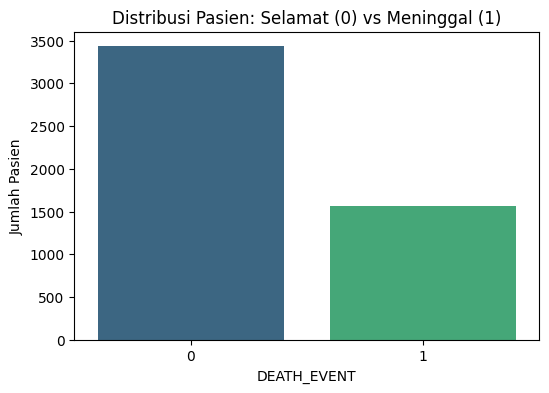

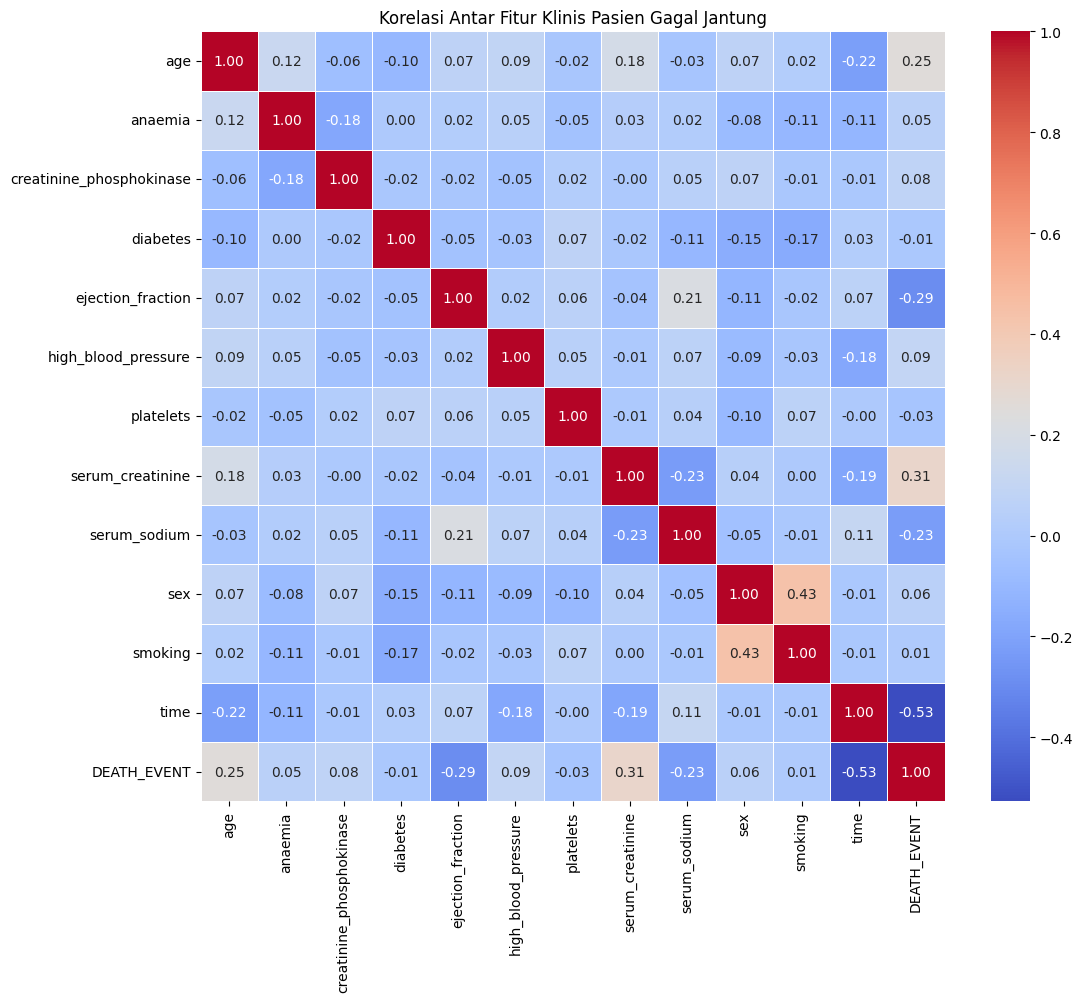

In [4]:
# 1. Mengecek struktur data dan tipe data
print("--- Informasi Tipe Data ---")
df.info()

# 2. Mengecek apakah ada data yang kosong (Missing Values)
print("\n--- Jumlah Missing Value per Kolom ---")
print(df.isnull().sum())

# 3. Melihat ringkasan statistik (rata-rata, nilai min, max) dari fitur angka
print("\n--- Statistik Deskriptif ---")
display(df.describe())

# 4. Visualisasi Distribusi Target (DEATH_EVENT)
# Ini penting untuk melihat apakah data kita seimbang (balanced) atau jomplang
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DEATH_EVENT', palette='viridis')
plt.title('Distribusi Pasien: Selamat (0) vs Meninggal (1)')
plt.xlabel('DEATH_EVENT')
plt.ylabel('Jumlah Pasien')
plt.show()

# 5. Visualisasi Heatmap Korelasi
# Untuk melihat hubungan antar fitur klinis (misalnya hubungan umur dengan risiko)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Antar Fitur Klinis Pasien Gagal Jantung')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# 1. Menghapus kolom 'time' untuk mencegah Data Leakage
print(f"Shape awal dataset: {df.shape}")
df_clean = df.drop(columns=['time'])
print(f"Shape setelah kolom 'time' dibuang: {df_clean.shape}")

# 2. Mengecek dan Menghapus Data Duplikat
duplicates = df_clean.duplicated().sum()
print(f"\nJumlah data duplikat ditemukan: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Data duplikat telah berhasil dihapus!")

# 3. Normalisasi / Standarisasi Fitur Numerik
# Saya hanya menstandarkan fitur angka (numerik), fitur boolean (0/1) dibiarkan saja
numeric_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium']

scaler = StandardScaler()
df_clean[numeric_features] = scaler.fit_transform(df_clean[numeric_features])
print("\nStandarisasi fitur numerik berhasil dilakukan!")

# 4. Menyimpan dataset yang sudah bersih untuk tahapan Modelling nanti
# Simpan ke file baru agar data asli tetap utuh
output_file = 'heart_failure_preprocessing.csv'
df_clean.to_csv(output_file, index=False)
print(f"\nDataset bersih siap pakai telah disimpan dengan nama: {output_file}")

# Menampilkan hasil akhir data yang sudah bersih
display(df_clean.head())

Shape awal dataset: (5000, 13)
Shape setelah kolom 'time' dibuang: (5000, 12)

Jumlah data duplikat ditemukan: 3686
Data duplikat telah berhasil dihapus!

Standarisasi fitur numerik berhasil dilakukan!

Dataset bersih siap pakai telah disimpan dengan nama: heart_failure_preprocessing.csv


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,-0.470044,0,0.175919,0,0.620145,0,-0.004278,-0.057293,0.075103,1,1,0
1,0.369442,0,-0.535837,0,-1.116207,0,0.387308,3.640390,-1.523969,1,0,0
2,-1.309531,0,0.005180,1,0.012421,0,0.518960,-0.457042,0.760420,0,0,0
3,-0.050301,1,0.182090,1,0.186057,1,0.603593,-0.157230,-2.437725,1,0,0
4,2.887901,1,0.005180,0,-0.682119,0,1.854279,0.642269,-1.067091,1,0,1
